In [4]:
import numpy as np
import matplotlib.pyplot as plt
import pandas as pd
import seaborn as sns

In [3]:
df=pd.read_csv('MagicBricks.csv')

In [3]:
df.head()

,Area,BHK,Bathroom,Furnishing,Locality,Parking,Price,Status,Transaction,Type,Per_Sqft,DataSource
0,800.0,3,2.0,Semi-Furnished,Rohini Sector 25,1.0,6500000,Ready_to_move,New_Property,Builder_Floor,NaN,Original
1,750.0,2,2.0,Semi-Furnished,"J R Designers Floors, Rohini Sector 24",1.0,5000000,Ready_to_move,New_Property,Apartment,6667.0,Original
2,950.0,2,2.0,Furnished,"Citizen Apartment, Rohini Sector 13",1.0,15500000,Ready_to_move,Resale,Apartment,6667.0,Original
3,600.0,2,2.0,Semi-Furnished,Rohini Sector 24,1.0,4200000,Ready_to_move,Resale,Builder_Floor,6667.0,Original
4,650.0,2,2.0,Semi-Furnished,Rohini Sector 24 carpet area 650 sqft status R...,1.0,6200000,Ready_to_move,New_Property,Builder_Floor,6667.0,Original


In [4]:
df.shape()

TypeError: 'tuple' object is not callable

In [5]:
df.shape

(1269, 12)

In [6]:
df.isnull().sum()

Area             0
BHK              0
Bathroom         2
Furnishing       5
Locality         0
Parking         33
Price            0
Status           0
Transaction      0
Type             5
Per_Sqft       241
DataSource       0
dtype: int64

In [7]:
#First we are  find replacing missing value in per _sqft

In [8]:
df['Per_Sqft']=df['Per_Sqft'].fillna(df['Price']/df['Area'])

In [9]:
#Second We are go replace missing value of Parking,Bathroom,Furnishing and Type

In [10]:
df['Parking'].fillna(df['Parking'].mode()[0], inplace=True)
df['Bathroom'].fillna(df['Bathroom'].mode()[0], inplace=True)
df['Furnishing'].fillna(df['Furnishing'].mode()[0], inplace=True)
df['Type'].fillna(df['Type'].mode()[0], inplace=True)


C:\Users\Saytam Pandey\AppData\Local\Temp\ipykernel_57280\2092832132.py:1: FutureWarning: A value is trying to be set on a copy of a DataFrame or Series through chained assignment using an inplace method.
The behavior will change in pandas 3.0. This inplace method will never work because the intermediate object on which we are setting values always behaves as a copy.

For example, when doing 'df[col].method(value, inplace=True)', try using 'df.method({col: value}, inplace=True)' or df[col] = df[col].method(value) instead, to perform the operation inplace on the original object.


  df['Parking'].fillna(df['Parking'].mode()[0], inplace=True)
C:\Users\Saytam Pandey\AppData\Local\Temp\ipykernel_57280\2092832132.py:2: FutureWarning: A value is trying to be set on a copy of a DataFrame or Series through chained assignment using an inplace method.
The behavior will change in pandas 3.0. This inplace method will never work because the intermediate object on which we are setting values always 

In [11]:
df.isnull().sum()

Area           0
BHK            0
Bathroom       0
Furnishing     0
Locality       0
Parking        0
Price          0
Status         0
Transaction    0
Type           0
Per_Sqft       0
DataSource     0
dtype: int64

In [12]:
df.dtype  #It is data type (we define) each  coulmn 

AttributeError: 'DataFrame' object has no attribute 'dtype'

In [13]:
df.dtypes #Sorry

Area           float64
BHK              int64
Bathroom       float64
Furnishing      object
Locality        object
Parking        float64
Price            int64
Status          object
Transaction     object
Type            object
Per_Sqft       float64
DataSource      object
dtype: object

In [14]:
#TyeCasting

In [15]:
df[['BHK','Price']].astype('float64')

,BHK,Price
0,3.0,6500000.0
1,2.0,5000000.0
2,2.0,15500000.0
3,2.0,4200000.0
4,2.0,6200000.0
...,...,...
1264,4.0,75000000.0
1265,2.0,21000000.0
1266,3.0,16500000.0
1267,1.0,3500000.0


In [16]:
#Unique Value count

In [17]:
df.nunique()

Area           315
BHK              8
Bathroom         7
Furnishing       3
Locality       369
Parking          9
Price          285
Status           2
Transaction      2
Type             2
Per_Sqft       439
DataSource       2
dtype: int64

In [18]:
print(df['Area'].value_counts(),'\n', df['BHK'].value_counts(),'\n', df['Bathroom'].value_counts(),'\n', df['Parking'].value_counts(),'\n', df['Furnishing'].value_counts(),'\n', df['Status'].value_counts(),'\n', df['Transaction'].value_counts(),'\n', df['Type'].value_counts(),'\n', df['Per_Sqft'].value_counts())
#It is use find value count for each value

Area
900.0      68
1500.0     51
1800.0     49
1000.0     43
1600.0     38
           ..
150.0       1
3250.0      1
4000.0      1
5500.0      1
11050.0     1
Name: count, Length: 315, dtype: int64 
 BHK
3     545
2     370
4     222
1      97
5      27
6       6
7       1
10      1
Name: count, dtype: int64 
 Bathroom
2.0    556
3.0    359
1.0    147
4.0    140
5.0     57
6.0      7
7.0      3
Name: count, dtype: int64 
 Parking
1.0      833
2.0      346
3.0       55
4.0       16
5.0        7
39.0       7
114.0      3
9.0        1
10.0       1
Name: count, dtype: int64 
 Furnishing
Semi-Furnished    719
Unfurnished       365
Furnished         185
Name: count, dtype: int64 
 Status
Ready_to_move    1194
Almost_ready       75
Name: count, dtype: int64 
 Transaction
Resale          786
New_Property    483
Name: count, dtype: int64 
 Type
Builder_Floor    674
Apartment        595
Name: count, dtype: int64 
 Per_Sqft
12500.000000    37
3524.000000     28
6667.000000     27
14818.000000    

In [19]:
df['Area_Yards']=df['Area']/9 
#Adding new area column in Sq Yards for better understanding of area

In [20]:
df['Locality'].unique()  
#Grouping the House Locality

array(['Rohini Sector 25', 'J R Designers Floors, Rohini Sector 24',
       'Citizen Apartment, Rohini Sector 13', 'Rohini Sector 24',
       'Rohini Sector 24 carpet area 650 sqft status Ready to Move floor 4 out of 4 floors transaction New Property furnishing Semi-Furnished facing East overlooking Garden/Park, Main Road car parking 1 Open bathroom 2 balcony 1 ownership Freehold Newly Constructed Property Newly Constructed Property East Facing Property 2BHK Newly build property for Sale. A House is waiting for a Friendly Family to make it a lovely home.So please come and make his house feel alive once again. read more Contact Agent View Phone No. Share Feedback Garima properties Certified Agent Trusted by Users Genuine Listings Market Knowledge',
       'Delhi Homes, Rohini Sector 24', 'Rohini Sector 21',
       'Rohini Sector 22', 'Rohini Sector 20',
       'Rohini Sector 8 How Auctions work? The borrower has the physical possession of the Property. However the lender (Bank) can lega

In [21]:
def grp_local(locality):
    locality = locality.lower() # avoid case sensitive
    if 'rohini' in locality:
        return 'Rohini Sector'
    elif 'dwarka' in locality:
        return 'Dwarka Sector'
    elif 'shahdara' in locality:
        return 'Shahdara'
    elif 'vasant' in locality:
        return 'Vasant Kunj'
    elif 'paschim' in locality:
        return 'Paschim Vihar'
    elif 'alaknanda' in locality:
        return 'Alaknanda'
    elif 'vasundhar' in locality:
        return 'Vasundhara Enclave'
    elif 'punjabi' in locality:
        return 'Punjabi Bagh'
    elif 'kalkaji' in locality:
        return 'Kalkaji'
    elif 'lajpat' in locality:
        return 'Lajpat Nagar'
    else:
        return 'Other'

df['Locality'] = df['Locality'].apply(grp_local)

In [22]:
df['Locality']=df['Locality'].apply(grp_local)

In [23]:
df['Locality'].value counts()  # this give error becacuse we not us '_'.

SyntaxError: invalid syntax (2292435460.py, line 1)

In [24]:
df['Locality'].value_counts() 

Locality
Other                 721
Lajpat Nagar           91
Dwarka Sector          88
Rohini Sector          76
Shahdara               75
Alaknanda              58
Vasant Kunj            36
Kalkaji                33
Punjabi Bagh           31
Paschim Vihar          30
Vasundhara Enclave     30
Name: count, dtype: int64

In [25]:
# Using Z - score to remove outliers
from scipy import stats
# Z score
z = np.abs(stats.zscore(df[df.dtypes[df.dtypes != 'object'].index]))
# Removing outliers
df = df[(z < 3).all(axis=1)]

In [26]:
df.describe()

,Area,BHK,Bathroom,Parking,Price,Per_Sqft,Area_Yards
count,1199.000000,1199.000000,1199.000000,1199.000000,1.199000e+03,1199.000000,1199.000000
mean,1297.243739,2.735613,2.485405,1.412844,1.859028e+07,12665.566047,144.138193
std,748.831134,0.859587,0.951887,0.719768,1.775587e+07,8429.761731,83.203459
min,28.000000,1.000000,1.000000,1.000000,1.000000e+06,1250.000000,3.111111
25%,800.000000,2.000000,2.000000,1.000000,5.510000e+06,6526.888889,88.888889
50%,1150.000000,3.000000,2.000000,1.000000,1.360000e+07,11111.000000,127.777778
75%,1600.000000,3.000000,3.000000,2.000000,2.490000e+07,16661.114812,177.777778
max,5220.000000,5.000000,5.000000,10.000000,9.300000e+07,72000.000000,580.000000


In [28]:
df.head(1100)

,Area,BHK,Bathroom,Furnishing,Locality,Parking,Price,Status,Transaction,Type,Per_Sqft,DataSource,Area_Yards
0,800.0,3,2.0,Semi-Furnished,Rohini Sector,1.0,6500000,Ready_to_move,New_Property,Builder_Floor,8125.0,Original,88.888889
1,750.0,2,2.0,Semi-Furnished,Rohini Sector,1.0,5000000,Ready_to_move,New_Property,Apartment,6667.0,Original,83.333333
2,950.0,2,2.0,Furnished,Rohini Sector,1.0,15500000,Ready_to_move,Resale,Apartment,6667.0,Original,105.555556
3,600.0,2,2.0,Semi-Furnished,Rohini Sector,1.0,4200000,Ready_to_move,Resale,Builder_Floor,6667.0,Original,66.666667
4,650.0,2,2.0,Semi-Furnished,Rohini Sector,1.0,6200000,Ready_to_move,New_Property,Builder_Floor,6667.0,Original,72.222222
...,...,...,...,...,...,...,...,...,...,...,...,...,...
1155,1200.0,2,2.0,Semi-Furnished,Alaknanda,2.0,17500000,Ready_to_move,Resale,Apartment,12500.0,Original,133.333333
1156,1400.0,2,2.0,Semi-Furnished,Alaknanda,2.0,14000000,Ready_to_move,Resale,Apartment,12500.0,Original,155.555556
1157,1500.0,3,3.0,Semi-Furnished,Alaknanda,2.0,21000000,Ready_to_move,Resale,Apartment,12500.0,Original,166.666667
1158,1320.0,3,2.0,Unfurnished,Alaknanda,2.0,15600000,Ready_to_move,Resale,Apartment,12500.0,Original,146.666667


In [29]:
df.head(10)

,Area,BHK,Bathroom,Furnishing,Locality,Parking,Price,Status,Transaction,Type,Per_Sqft,DataSource,Area_Yards
0,800.0,3,2.0,Semi-Furnished,Rohini Sector,1.0,6500000,Ready_to_move,New_Property,Builder_Floor,8125.0,Original,88.888889
1,750.0,2,2.0,Semi-Furnished,Rohini Sector,1.0,5000000,Ready_to_move,New_Property,Apartment,6667.0,Original,83.333333
2,950.0,2,2.0,Furnished,Rohini Sector,1.0,15500000,Ready_to_move,Resale,Apartment,6667.0,Original,105.555556
3,600.0,2,2.0,Semi-Furnished,Rohini Sector,1.0,4200000,Ready_to_move,Resale,Builder_Floor,6667.0,Original,66.666667
4,650.0,2,2.0,Semi-Furnished,Rohini Sector,1.0,6200000,Ready_to_move,New_Property,Builder_Floor,6667.0,Original,72.222222
5,1300.0,4,3.0,Semi-Furnished,Rohini Sector,1.0,15500000,Ready_to_move,New_Property,Builder_Floor,6667.0,Original,144.444444
6,1350.0,4,3.0,Semi-Furnished,Rohini Sector,1.0,10000000,Ready_to_move,Resale,Builder_Floor,6667.0,Original,150.000000
7,650.0,2,2.0,Semi-Furnished,Rohini Sector,1.0,4000000,Ready_to_move,New_Property,Apartment,6154.0,Original,72.222222
8,985.0,3,3.0,Unfurnished,Rohini Sector,1.0,6800000,Almost_ready,New_Property,Builder_Floor,6154.0,Original,109.444444
9,1300.0,4,4.0,Semi-Furnished,Rohini Sector,1.0,15000000,Ready_to_move,New_Property,Builder_Floor,6154.0,Original,144.444444


In [30]:

#We go analysis data -->Exploratory Data Analysis

In [ ]:
#1: --> Area of Houses

Text(0.5, 1.0, 'Area in Yards')

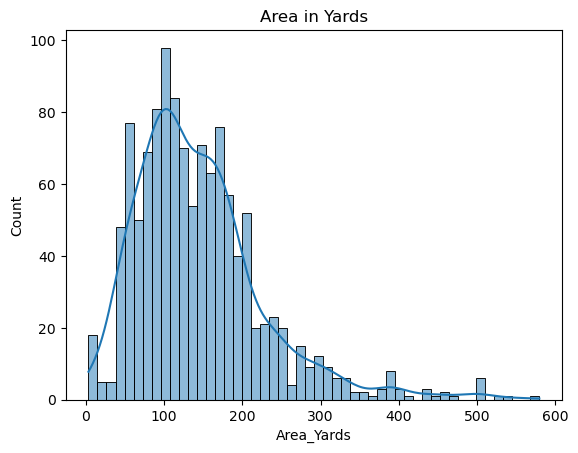

In [31]:
sns.histplot(x = df['Area_Yards'],  kde = True, bins = 50).set_title('Area in Yards')

In [32]:
#1. Lookking at the distribution of Area if houses in delhi most of the houses have area between 80 - 200 sq. yards. 
#2. This means that most of the houses in delhi are small houses and there are few house having area near 300 sq yards. 
#3. Whereas thery are very few houses having area more than 400 sq yards. 
#4. This representation helps us to know about availability of space in delhi.

In [33]:
#2 --> BHK

Text(0.5, 1.0, 'BHK')

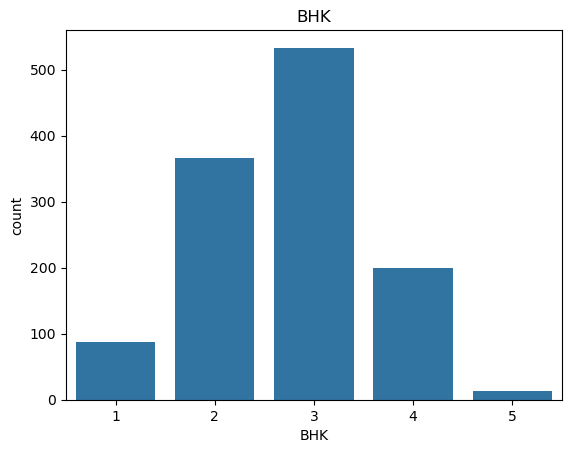

In [34]:
sns.countplot(x='BHK',data=df).set_title('BHK')

In [35]:
#1 ;BHK - Bedroom Hall Kitchen. From this graph we can get a little idea about the design of most of
#2:houses in delhi. Most of houses are 3 BHK followed by 2, 4, 1 and 5 BHK houses. Majority of the houses
#3:have area between 80-200 sq. yards. Houses with area near 200 yards can have maximum 3 bedrooms, for houses with area near 100 can have 2 bedrooms and 1 bedroom for houses with area less than 80 sq yards. Moreover whoses having area more than 300 are less in number so the count of 4BHK and 5BHK. Thus, there is a relation between the BHK and area of house, with this relation we can get a idea about the structure of houses.

In [36]:
#BathRoom

Text(0.5, 1.0, 'Bathroom')

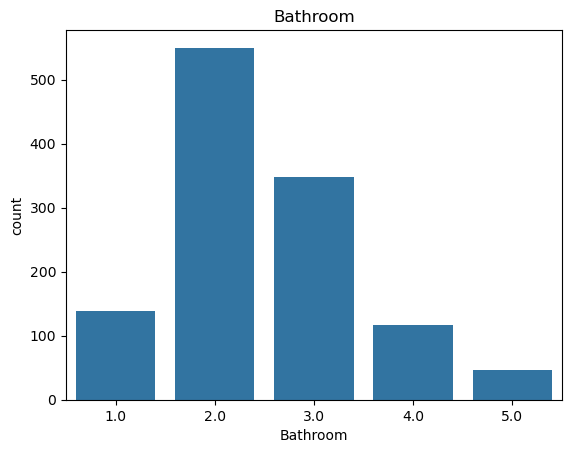

In [37]:
sns.countplot(x = 'Bathroom', data = df).set_title('Bathroom')

In [38]:
#Furnishing

Text(0.5, 1.0, 'Furnishing')

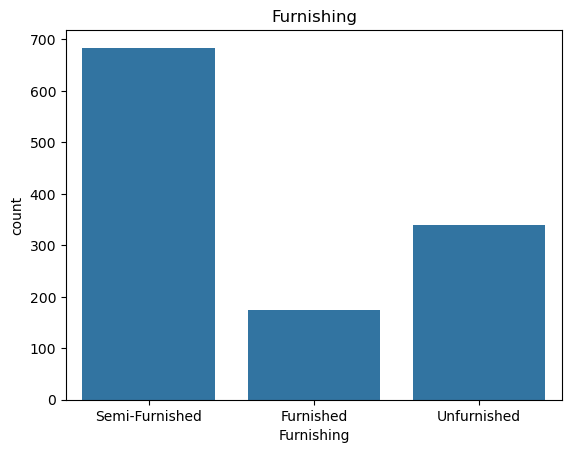

In [39]:
sns.countplot(x='Furnishing',data=df).set_title('Furnishing')

In [40]:
#Locality

([0, 1, 2, 3, 4, 5, 6, 7, 8, 9, 10],
 [Text(0, 0, 'Rohini Sector'),
  Text(1, 0, 'Lajpat Nagar'),
  Text(2, 0, 'Dwarka Sector'),
  Text(3, 0, 'Other'),
  Text(4, 0, 'Vasant Kunj'),
  Text(5, 0, 'Shahdara'),
  Text(6, 0, 'Paschim Vihar'),
  Text(7, 0, 'Alaknanda'),
  Text(8, 0, 'Vasundhara Enclave'),
  Text(9, 0, 'Punjabi Bagh'),
  Text(10, 0, 'Kalkaji')])

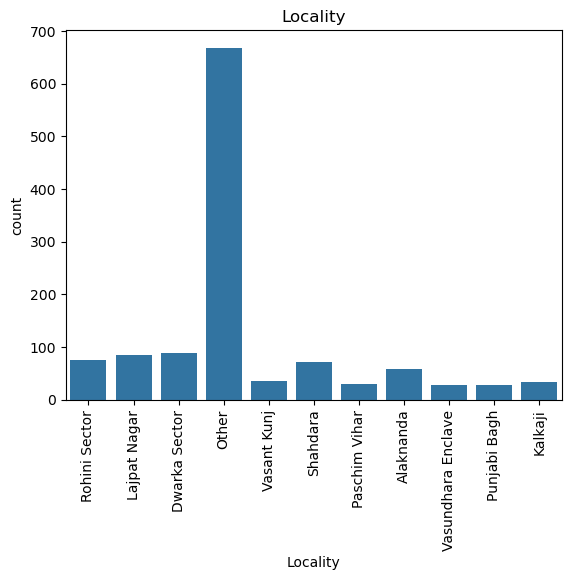

In [41]:
sns.countplot(x = 'Locality', data = df).set_title('Locality')
plt.xticks(rotation = 90)

In [42]:
# Parking

Text(0.5, 1.0, 'Parking')

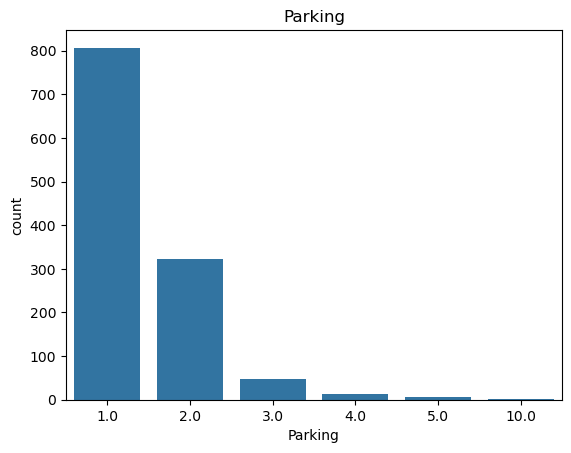

In [43]:
sns.countplot(x = 'Parking', data = df).set_title('Parking')

In [44]:
#Status

Text(0.5, 1.0, 'Status of the Property')

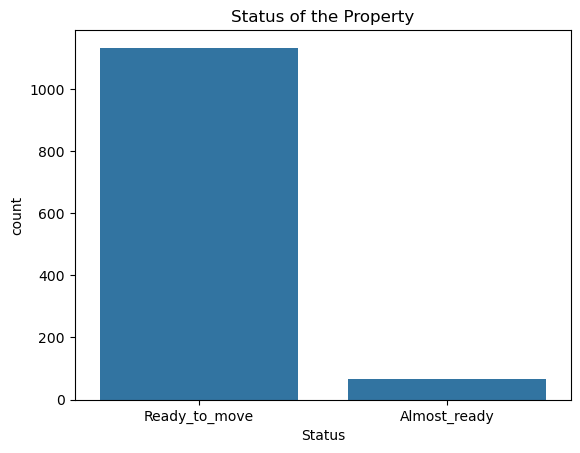

In [45]:
sns.countplot(x = 'Status', data = df).set_title('Status of the Property')

In [46]:
#Transaction Type

Text(0.5, 1.0, 'Transaction Type')

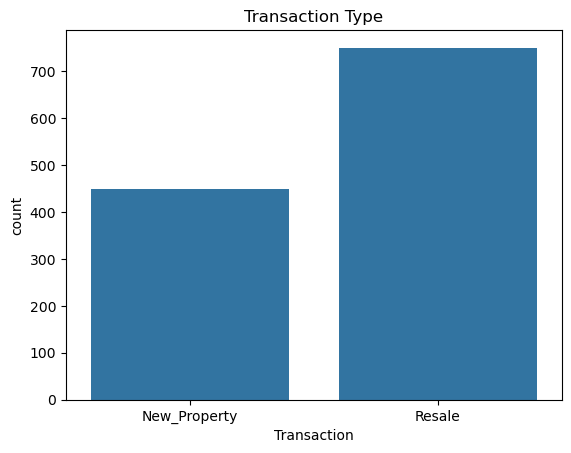

In [47]:
sns.countplot(x='Transaction', data=df).set_title('Transaction Type')

In [48]:
#House Type

Text(0.5, 1.0, 'Type of House')

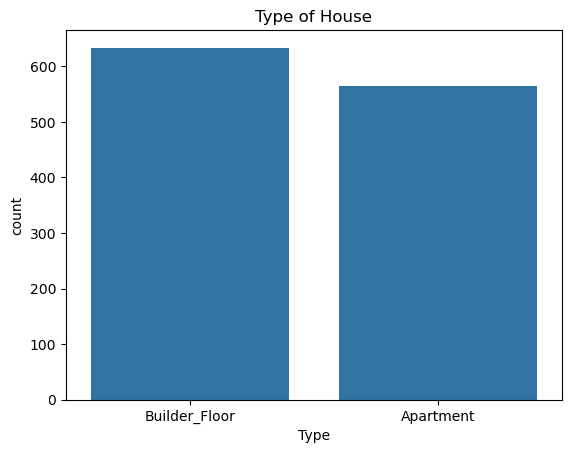

In [49]:
sns.countplot(x='Type',data=df).set_title('Type of House')

In [50]:
#Area and Price

<Axes: xlabel='Area_Yards', ylabel='Price'>

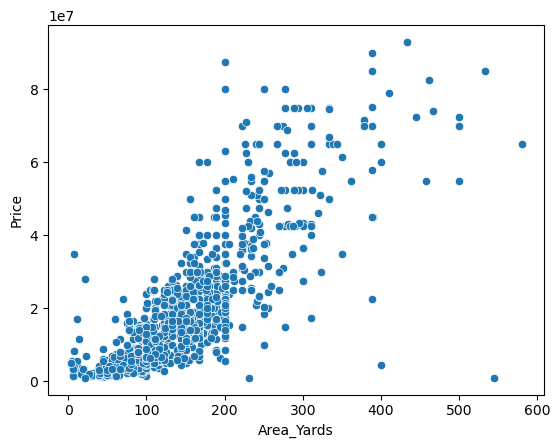

In [51]:
sns.scatterplot(x = 'Area_Yards', y = 'Price', data = df) # This is show LinearRegression

In [52]:
#BHK and Price

Text(0.5, 1.0, 'BHK vs Price')

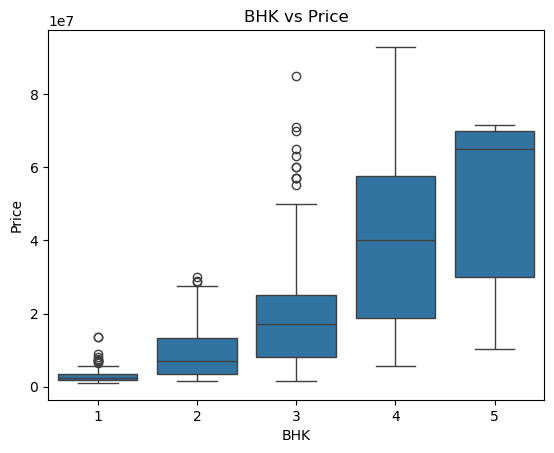

In [53]:
sns.boxplot(x = 'BHK', y = 'Price', data = df).set_title('BHK vs Price')

Text(0.5, 1.0, 'Bathroom vs Price')

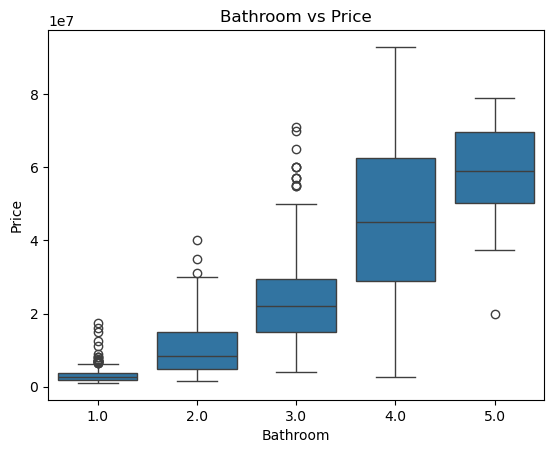

In [54]:
#Bathroom count and Price
sns.boxplot(x = 'Bathroom', y = 'Price', data = df).set_title('Bathroom vs Price')

In [55]:
#Parking and Price

Text(0.5, 1.0, 'Parking vs Price')

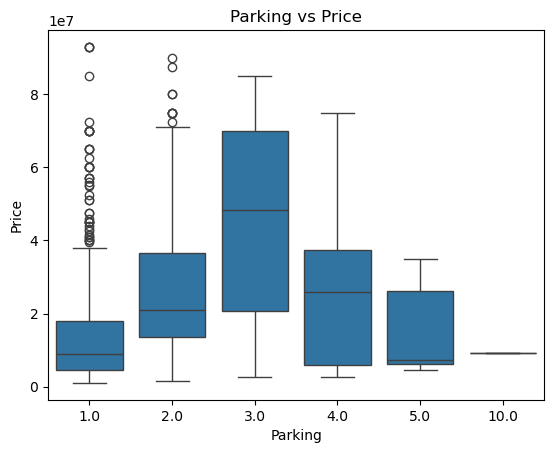

In [56]:
sns.boxplot(x = 'Parking', y = 'Price', data = df).set_title('Parking vs Price')


In [57]:
#Locality and Price

([0, 1, 2, 3, 4, 5, 6, 7, 8, 9, 10],
 [Text(0, 0, 'Rohini Sector'),
  Text(1, 0, 'Lajpat Nagar'),
  Text(2, 0, 'Dwarka Sector'),
  Text(3, 0, 'Other'),
  Text(4, 0, 'Vasant Kunj'),
  Text(5, 0, 'Shahdara'),
  Text(6, 0, 'Paschim Vihar'),
  Text(7, 0, 'Alaknanda'),
  Text(8, 0, 'Vasundhara Enclave'),
  Text(9, 0, 'Punjabi Bagh'),
  Text(10, 0, 'Kalkaji')])

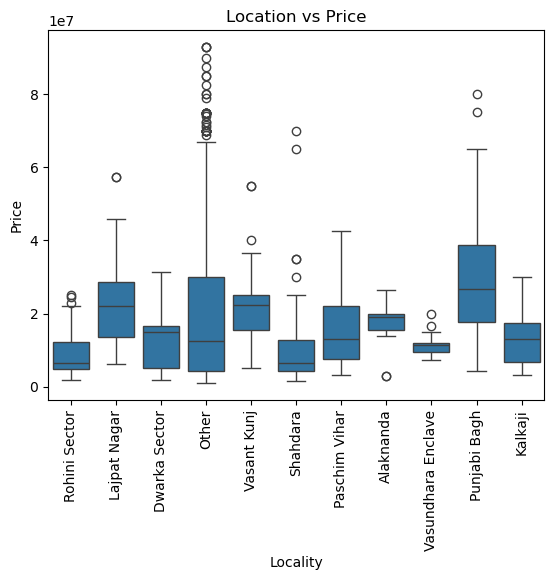

In [58]:
sns.boxplot(x='Locality', y='Price', data=df).set_title('Location vs Price')
plt.xticks(rotation=90)

In [59]:
#Furnishing and Price

Text(0.5, 1.0, 'Furnishing vs Price')

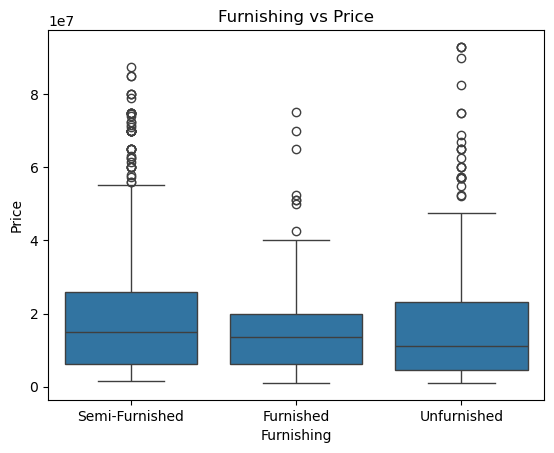

In [60]:
sns.boxplot(x = 'Furnishing', y = 'Price', data = df).set_title('Furnishing vs Price')

In [61]:
#Status and Price

Text(0.5, 1.0, 'Price vs Status')

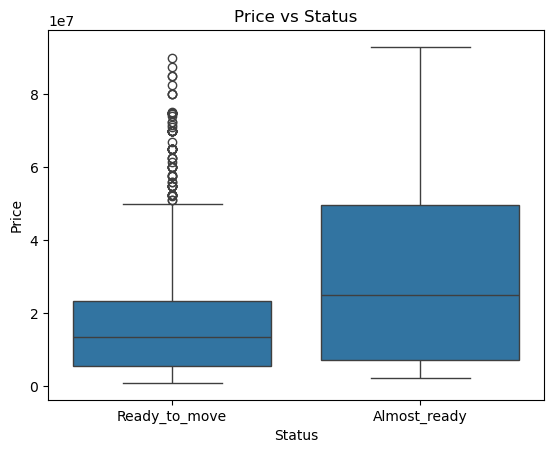

In [62]:
sns.boxplot(x = 'Status', y = 'Price', data = df).set_title('Price vs Status')

In [63]:
#Transaction Type and Price

Text(0.5, 1.0, 'Transaction vs Price')

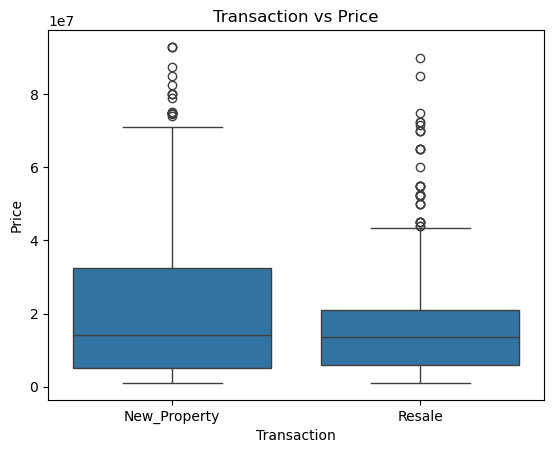

In [64]:
sns.boxplot(x = 'Transaction', y = 'Price', data = df).set_title('Transaction vs Price')

In [65]:
#Property Type and Price

Text(0.5, 1.0, 'Price vs Type')

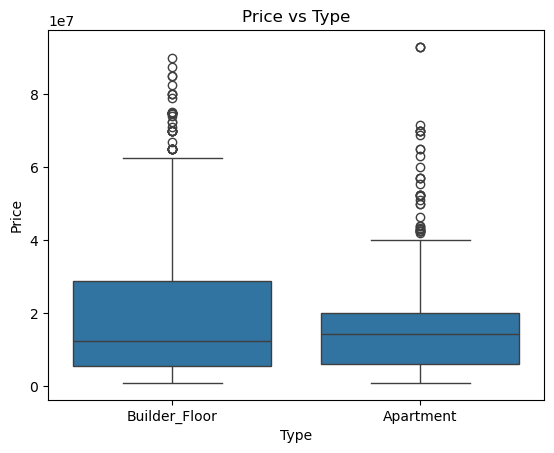

In [66]:
sns.boxplot(x = 'Type', y = 'Price', data = df).set_title('Price vs Type')

In [67]:
#Data Preprocessing 2

In [70]:
from sklearn.preprocessing import LabelEncoder
le = LabelEncoder()

# Columns for label encoding
cols = ['Furnishing', 'Locality', 'Status', 'Transaction', 'Type']

for i in cols:
    le.fit(df[i])
    df[i] = le.transform(df[i])
    print(i, df[i].unique())

Furnishing [1 0 2]
Locality [ 7  3  1  4  9  8  5  0 10  6  2]
Status [1 0]
Transaction [0 1]
Type [1 0]


C:\Users\Saytam Pandey\AppData\Local\Temp\ipykernel_57280\3293860172.py:9: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  df[i] = le.transform(df[i])
C:\Users\Saytam Pandey\AppData\Local\Temp\ipykernel_57280\3293860172.py:9: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  df[i] = le.transform(df[i])
C:\Users\Saytam Pandey\AppData\Local\Temp\ipykernel_57280\3293860172.py:9: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value

In [71]:
#Normalizing the continuous features

In [72]:

from sklearn.preprocessing import MinMaxScaler
min_max = MinMaxScaler()
df[['Area', 'Price', 'Per_Sqft', 'Area_Yards']] = MinMaxScaler().fit_transform(df[['Area', 'Price', 'Per_Sqft', 'Area_Yards']])

C:\Users\Saytam Pandey\AppData\Local\Temp\ipykernel_57280\188674309.py:3: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  df[['Area', 'Price', 'Per_Sqft', 'Area_Yards']] = MinMaxScaler().fit_transform(df[['Area', 'Price', 'Per_Sqft', 'Area_Yards']])


In [73]:
df.head()

,Area,BHK,Bathroom,Furnishing,Locality,Parking,Price,Status,Transaction,Type,Per_Sqft,DataSource,Area_Yards
0,0.148690,3,2.0,1,7,1.0,0.059783,1,0,1,0.097173,Original,0.148690
1,0.139060,2,2.0,1,7,1.0,0.043478,1,0,0,0.076565,Original,0.139060
2,0.177581,2,2.0,0,7,1.0,0.157609,1,1,0,0.076565,Original,0.177581
3,0.110169,2,2.0,1,7,1.0,0.034783,1,1,1,0.076565,Original,0.110169
4,0.119800,2,2.0,1,7,1.0,0.056522,1,0,1,0.076565,Original,0.119800


In [74]:
#Coorelation Matrix HeatMap

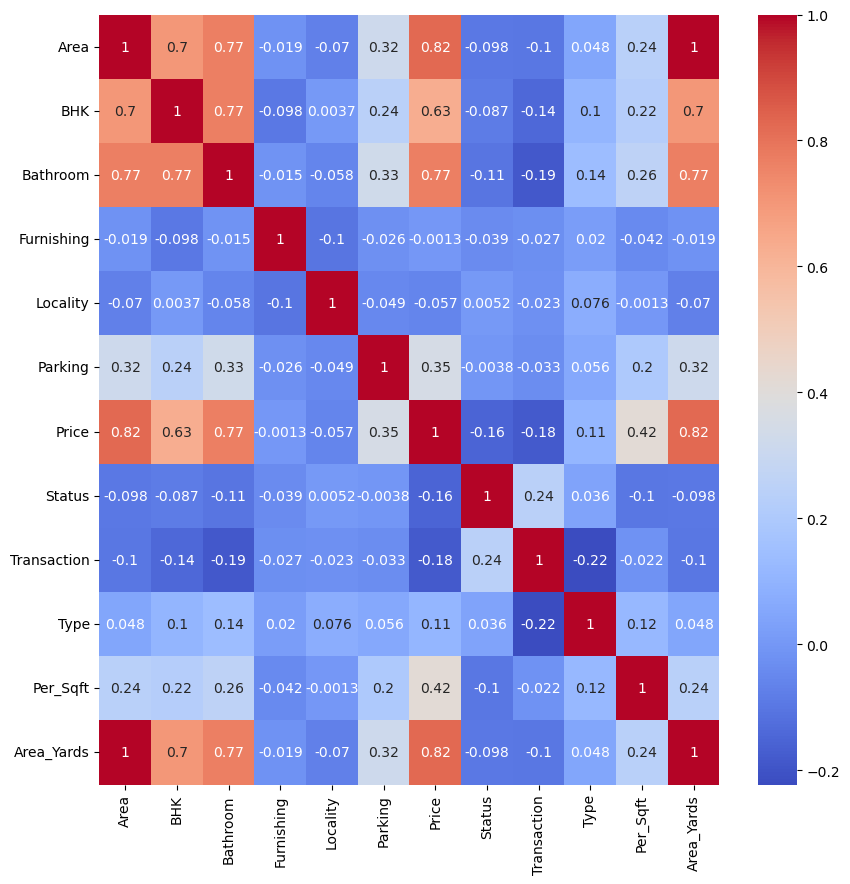

In [77]:
plt.figure(figsize=(10, 10))
sns.heatmap(df.select_dtypes(include=['number']).corr(), 
            annot=True, 
            cmap='coolwarm')
plt.show()

In [78]:
#Train Test Spilt

In [79]:
#Dropping Per_Sqft column

In [85]:
df.drop(['Per_Sqft'],axis=1,inplace=True)

KeyError: "['Per_Sqft'] not found in axis"

In [87]:
df.columns

Index(['Area', 'BHK', 'Bathroom', 'Furnishing', 'Locality', 'Parking', 'Price',
       'Status', 'Transaction', 'Type', 'DataSource', 'Area_Yards'],
      dtype='object')

In [88]:
df.drop(columns=['Area_Yards'], inplace=True)

In [89]:
from sklearn.model_selection import train_test_split
X_train, X_test, y_train, y_test = train_test_split(df.drop('Price',axis=1), df['Price'], test_size=0.2, random_state=42)

In [90]:
#Price Prediction
#I will be using the following models:

#1 : Decision Tree Regressor
#2 : Random Forest Regressor

In [3]:
from sklearn.tree import DecisionTreeRegressor

#creating Decision Tree Regressor object
dtr = DecisionTreeRegressor()

In [92]:
#Hypertuning the model with GridSearchCV  --> This use find bestparametre value

In [4]:
from sklearn.model_selection import GridSearchCV

# Defining parameters
parameters  = {'max_depth':[2,4,6,8],
               'min_samples_split':[2,4,6,8],
               'min_samples_leaf':[1,2,3,4],
               'max_features':['auto','sqrt','log2'],
               'random_state':[0,42]}

# Creating GridSearchCV object
grid_search = GridSearchCV(dtr, parameters, cv=5, scoring='neg_mean_squared_error')

# Fitting data to grid search object
grid_search.fit(X_train, y_train)

# Best parameters
print("Best parameters: ", grid_search.best_params_)




NameError: name 'X_train' is not defined

In [96]:
dtr = DecisionTreeRegressor( max_depth=6, max_features='auto', min_samples_leaf = 1, min_samples_split = 8, random_state=42)
dtr

DecisionTreeRegressor(max_depth=6, max_features='auto', min_samples_split=8,
                      random_state=42)

In [5]:
dtr.fit(X_train, y_train)

NameError: name 'X_train' is not defined

In [98]:
dtr.score(X_train, y_train)

NotFittedError: This DecisionTreeRegressor instance is not fitted yet. Call 'fit' with appropriate arguments before using this estimator.

In [6]:
d_pred = dtr.predict(X_test)

NameError: name 'X_test' is not defined

In [5]:
dft = pd.DataFrame({'Actual': y_test, 'Predicted': d_pred})
dft.reset_index(drop=True, inplace=True)
dft.head(10)

NameError: name 'y_test' is not defined

In [6]:
ax = sns.distplot(dft['Actual'], color = 'r', label = 'Actual Price', hist = False)
sns.distplot(dft['Predicted'], color = 'g', label = 'Predicted Price', ax=ax, hist = False)

NameError: name 'dft' is not defined